In [11]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

In [14]:
qubit_name = 'q16'


current_dir = os.path.join(os.getcwd(),'data', qubit_name)
    
print(current_dir)
# current_dir = os.path.join(os.getcwd(), 'data', qubit_name)
files = os.listdir(current_dir)
for file in files:
    print(file)

/Users/asafsolonnikov/Developer/readout_optimization/data/q16
readout_fidelity_map_q16_with_kernel_with_twpa.json
.DS_Store
readout_fidelity_map_q16_with_kernel_with_twpa_1.json
readout_fidelity_map_q16_with_kernel_without_twpa_3.json
readout_fidelity_map_q16_with_kernel_with_twpa_2.json
readout_fidelity_map_q16_with_kernel_with_twpa_3.json
readout_fidelity_map_q16_with_kernel_without_twpa_2.json


In [ ]:
file_index = 1


def extract_data(file):
    with open(os.path.join(current_dir, file), 'r') as f:
        data = json.load(f)

    sweep_params = data['sweep_params']
    lengths = np.array(sweep_params['lengths'])
    amplitudes = np.array(sweep_params['amplitudes'])
    acquired_data = data['acquired_data']

    return lengths, amplitudes, acquired_data


def find_fidelity(acquired_data):

    fidelities = np.array([entry['fidelity'] for entry in acquired_data])

    return fidelities


def find_seperation(acquired_data):
    separations = np.array([entry['separation'] for entry in acquired_data])
    return separations

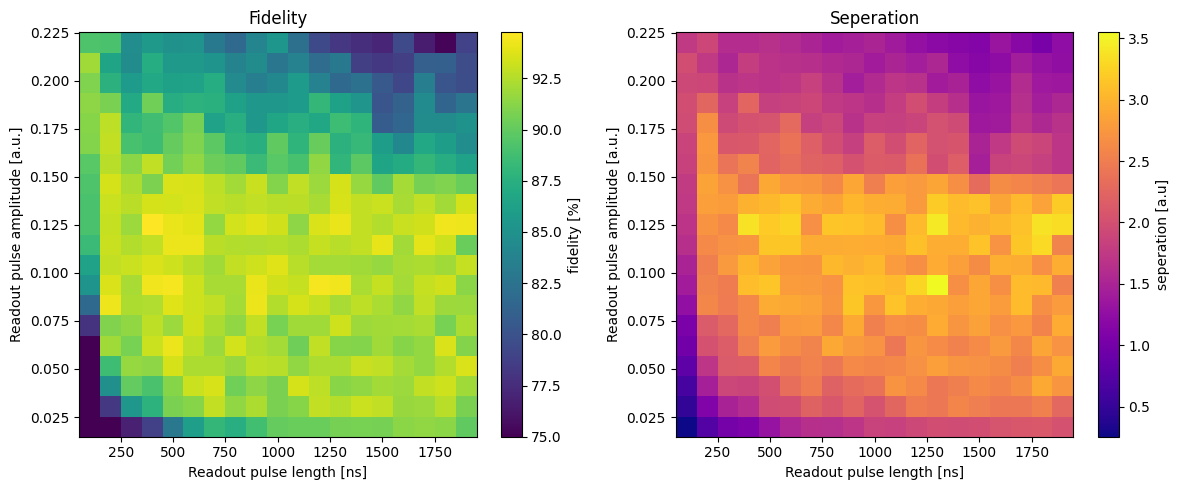

(np.float64(3.1941544552508794), np.float64(93.55))

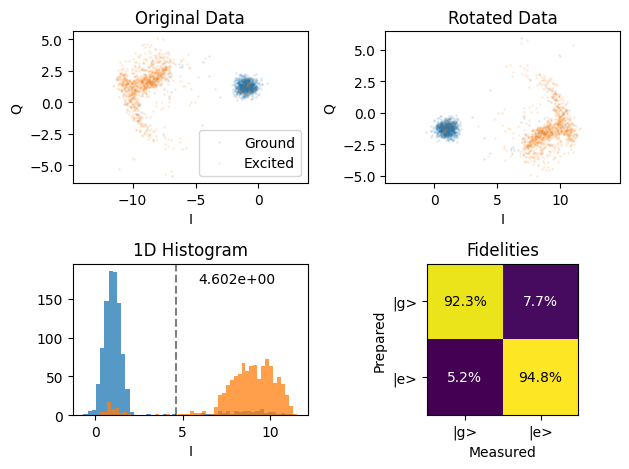

In [ ]:
from qhipu_lab.experiments.optimize_readout.utils import two_state_discriminator


def give_all(l,a,lengths,amplitudes):
    l_vec = np.abs(lengths-l)
    a_vec = np.abs(amplitudes-a)
    
    l_index = np.argmin(l_vec)
    a_index = np.argmin(a_vec)
    
    return str(lengths[l_index]), str(amplitudes[a_index])



def find_params(IQ_data, plot=False):

    I0 = np.array(IQ_data['ground']['I'])
    Q0 = np.array(IQ_data['ground']['Q'])
    I1 = np.array(IQ_data['excited']['I'])
    Q1 = np.array(IQ_data['excited']['Q'])

    _, _, fidelity, _, _, _, _ = two_state_discriminator(
        I0, Q0, I1, Q1, b_print=False, b_plot=plot)

    seperation = find_seperation(IQ_data)
    fidelity = fidelity

    return seperation, fidelity


def find_fidelity(IQ_data):
    I0 = np.array(IQ_data['ground']['I'])
    Q0 = np.array(IQ_data['ground']['Q'])
    I1 = np.array(IQ_data['excited']['I'])
    Q1 = np.array(IQ_data['excited']['Q'])

    _, _, fidelity, _, _, _, _ = two_state_discriminator(
        I0, Q0, I1, Q1, b_print=False, b_plot=False)

    return fidelity


def find_seperation(IQ_data):
    I0 = np.array(IQ_data['ground']['I'])
    Q0 = np.array(IQ_data['ground']['Q'])
    I1 = np.array(IQ_data['excited']['I'])
    Q1 = np.array(IQ_data['excited']['Q'])

    ground = I0 + 1j*Q0
    excited = I1 + 1j*Q0

    distance = np.mean(ground) - np.mean(excited)
    varience = np.var(ground)/2+np.var(excited)/2

    return np.abs(distance)/np.sqrt(varience)


def plot_2d(axs, file):
    with open(os.path.join(current_dir, file), 'r') as f:
        data = json.load(f)

    length_sweep, amplitude_sweep, acquired_data = extract_data(file)

    f_matrix = []
    for l in acquired_data.keys():
        f_vector = []
        for a in acquired_data[l].keys():
            f = acquired_data[l][a]['fidelity']
            f_vector.append(f)
        f_matrix.append(f_vector)

    f_matrix = np.array(f_matrix).T

    # axs[0].set_title(file)

    p = axs[0].pcolormesh(
        length_sweep/1e-9, amplitude_sweep, f_matrix, shading='auto')
    axs[0].set_xlabel('Readout pulse length [ns]')
    axs[0].set_ylabel('Readout pulse amplitude [a.u.]')
# plt.colorbar()

    for i, f in enumerate(f_matrix):
        axs[1].plot(length_sweep/1e-9, f, 'o-',
                    label=f'{amplitude_sweep[i]:.2f}')
        axs[1].grid()
        axs[1].set_xlabel('Readout pulse length [ns]')
        axs[1].set_ylabel('Fidelity')
        # axs[1].legend(title = 'amp',fontsize = 'small')
        axs[1].set_ylim(50, 100)
        axs[1].figure.show()
        axs[1].grid(True)
    plt.tight_layout()

    plt.show()





def find_params_matrix(acquired_data):
    
    fidelity_matrix = []
    seperation_matrix = []

    for l in acquired_data.keys():
        fidelity_vec = []
        seperation_vec = []
        for a in acquired_data[str(l)].keys():
            IQ_data = acquired_data[str(l)][str(a)]['IQ_data']
            f,s = find_params(IQ_data)
            fidelity_vec.append(f)
            seperation_vec.append(s)
            
        fidelity_matrix.append(fidelity_vec)
        seperation_matrix.append(seperation_vec)
        
    fidelity_matrix = np.array(fidelity_matrix).T
    seperation_matrix = np.array(seperation_matrix).T
    
    return fidelity_matrix, seperation_matrix


lengths, amplitudes, acquired_data = extract_data(files[0])


fidelity_matrix, seperation_matrix = find_params_matrix(acquired_data)



plt.figure(figsize=(12, 5))



plt.subplot(1, 2, 2)
plt.title('Seperation')

plt.pcolormesh(lengths/1e-9, amplitudes,
                fidelity_matrix, shading='auto',cmap='plasma')    

plt.xlabel('Readout pulse length [ns]')
plt.ylabel('Readout pulse amplitude [a.u.]')

plt.colorbar(label='seperation [a.u]')



plt.subplot(1, 2, 1)
plt.title('Fidelity')

plt.pcolormesh(lengths/1e-9, amplitudes,        
                seperation_matrix, shading='auto',vmin=75)
plt.xlabel('Readout pulse length [ns]')
plt.ylabel('Readout pulse amplitude [a.u.]')
plt.colorbar(label='fidelity [%]')

plt.tight_layout()
plt.show()


l,a = give_all(1250e-9,0.135,lengths,amplitudes)

IQ_data = acquired_data[l][a]['IQ_data']

find_params(IQ_data, plot=True)

        


In [6]:

for file in files:
    plot_iq_blobs(file, 1, 1)

NameError: name 'plot_iq_blobs' is not defined

/var/folders/5l/mx_yndbx4sq978lx9ht2346r0000gn/T/ipykernel_5079/3679077876.py:61: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  axs[1].figure.show()


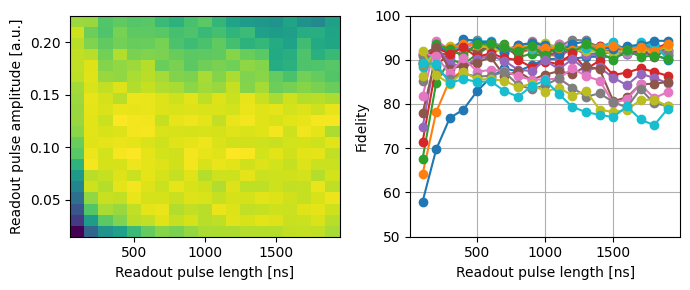

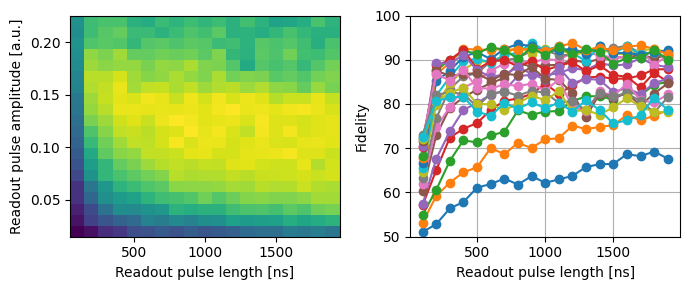

In [ ]:
for file in files:
    fig, axs = plt.subplots(1, 2, figsize=(7, 3))
    plot_2d(axs, file)

In [ ]:
from ipywidgets import interact, IntSlider


def sweep_len(i):
    plot_iq_blobs(files[2], i, 1)


interact(
    sweep_len,
    i=IntSlider(min=0, max=5-1, step=1, value=0, description='Index')
)

interactive(children=(IntSlider(value=0, description='Index', max=4), Output()), _dom_classes=('widget-interac…

<function __main__.sweep_len(i)>